## How to use this notebook

- **Single-run cells**: The first few code cells run one set of simulations for the three AI policies and are used by any Gantt or single-permit views.
- **Multi-run cells**: The later cells that call `run_multiple_simulations` run many simulations per policy and feed the aggregate statistics and box/whisker plots.
- **Workflow**: Run the single-run block first (to keep Gantt charts tied to one run), then run the multi-run block to update the aggregate visualizations.

In [1]:
from run_simulation import run_simulation, print_statistics, run_multiple_simulations
from visualize_permits import (
    visualize_all,
    plot_median_total_time_by_process,
    plot_gantt_one_random_permit_segment,
    plot_average_waiting_and_service_by_step,
)
import matplotlib.pyplot as plt
import numpy as np

# Common parameters for both analyses
NUM_PERMITS = 1200
RANDOM_SEED = 36

In [2]:
# Run all three simulations
print(f"Running standard simulation with {NUM_PERMITS} permits...")
# Edit these values to test additional assumptions.
SIMULATION_PARAMS = {
    "sequential": "standard",  # "standard", "parallel", "sequential"
    "simulation_duration": None,
    "pct_pre_approved": 0.02,
    "pct_custom": 0.90,
    "pct_self_cert": 0.08,
    "pct_like_for_like": 0.80,
    "pre_application_distribution": "lognormal_180",
    "review_duration_families": None,      # e.g. {"planning": "lognormal", "public_works": "normal", "fire": "triangular"}
    "review_duration_multipliers": None,   # e.g. {"planning": 1.2, "public_works": 1.0, "fire": 0.9, "special_zoning": 1.0, "agency_referral": 1.0}
    "planning_staff_count": 2,
    "planning_caseload_per_staff": 7,
    "public_works_staff_count": 3,
    "public_works_caseload_per_staff": 7,
    "fire_staff_count": 1,
    "fire_caseload_per_staff": 7,
}

common_run_kwargs = {
    "num_permits": NUM_PERMITS,
    "random_seed": RANDOM_SEED,
    **SIMULATION_PARAMS,
}

sim_standard = run_simulation(
    **common_run_kwargs,
    ai_review="none",
)

print(f"\nRunning initial AI check simulation with {NUM_PERMITS} permits...")
sim_initial = run_simulation(
    **common_run_kwargs,
    ai_review="initial_check",
)

print(f"\nRunning full AI review simulation with {NUM_PERMITS} permits...")
sim_full = run_simulation(
    **common_run_kwargs,
    ai_review="full_review",
)

Running standard simulation with 1200 permits...

Running initial AI check simulation with 1200 permits...

Running full AI review simulation with 1200 permits...


In [3]:
# Print statistics for each process
print("=== STANDARD PROCESS ===")
stats_standard = sim_standard.get_statistics()
print_statistics(stats_standard)

print("=== AI INITIAL CHECK PROCESS ===")
stats_initial = sim_initial.get_statistics()
print_statistics(stats_initial)

print("\n=== AI FULL REVIEW PROCESS ===")
stats_full = sim_full.get_statistics()
print_statistics(stats_full)

=== STANDARD PROCESS ===

SIMULATION STATISTICS

Total Completed Permits: 1200
Total In Progress: 0

--------------------------------------------------------------------------------
SEGMENT DISTRIBUTION
--------------------------------------------------------------------------------
  CUSTOM_LIKE                   :  835 (69.58%)
  CUSTOM_NON_LIKE               :  251 (20.92%)
  PRE_APPROVED_LIKE             :   18 ( 1.50%)
  PRE_APPROVED_NON_LIKE         :    7 ( 0.58%)
  SELF_CERT_LIKE                :   70 ( 5.83%)
  SELF_CERT_NON_LIKE            :   19 ( 1.58%)

--------------------------------------------------------------------------------
OVERALL PROCESSING TIME STATISTICS
--------------------------------------------------------------------------------
  Mean:     481.28 days
  Median:   480.35 days
  Std Dev:  195.13 days
  Min:       74.29 days
  Max:     1365.54 days

--------------------------------------------------------------------------------
PROCESSING TIME BY SEGMENT
-

In [4]:
# Run multiple simulations for each AI scenario to see aggregate behavior
N_RUNS = 10

# Edit these values to test additional assumptions across all AI scenarios.
SIMULATION_DURATION = None
MULTI_RUN_PARAMS = {
    "sequential": "standard",  # "standard", "parallel", "sequential"
    "pct_pre_approved": 0.02,
    "pct_custom": 0.90,
    "pct_self_cert": 0.08,
    "pct_like_for_like": 0.80,
    "pre_application_distribution": "lognormal_180",
    "review_duration_families": None,      # e.g. {"planning": "lognormal", "public_works": "normal", "fire": "triangular"}
    "review_duration_multipliers": None,   # e.g. {"planning": 1.2, "public_works": 1.0, "fire": 0.9, "special_zoning": 1.0, "agency_referral": 1.0}
    "planning_staff_count": 2,
    "planning_caseload_per_staff": 7,
    "public_works_staff_count": 3,
    "public_works_caseload_per_staff": 7,
    "fire_staff_count": 2,
    "fire_caseload_per_staff": 7,
}

scenario_params_list = [
    {"name": "Standard", **MULTI_RUN_PARAMS, "ai_review": "none"},
    {"name": "Initial AI Check", **MULTI_RUN_PARAMS, "ai_review": "initial_check"},
    {"name": "Full AI Review", **MULTI_RUN_PARAMS, "ai_review": "full_review"},
]

multi_run_kwargs = {
    "n_runs": N_RUNS,
    "num_permits": NUM_PERMITS,
    "simulation_duration": SIMULATION_DURATION,
    "base_seed": RANDOM_SEED,
    "scenario_params_list": scenario_params_list,
    "collect_permits": True,
}

multi_results = run_multiple_simulations(**multi_run_kwargs)

all_standard_permits: list = []
all_initial_permits: list = []
all_full_permits: list = []

for res in multi_results:
    scenario = res["scenario"]
    permits = res.get("permits", [])
    if scenario == "Standard":
        all_standard_permits.extend(permits)
    elif scenario == "Initial AI Check":
        all_initial_permits.extend(permits)
    elif scenario == "Full AI Review":
        all_full_permits.extend(permits)


def _print_summary(name: str, permits: list) -> None:
    if not permits:
        print(f"{name}: no completed permits across runs")
        return
    total_times = np.array(
        [
            p.ready_for_construction - p.created_at
            for p in permits
            if getattr(p, "ready_for_construction", None) is not None
        ]
    )
    if total_times.size == 0:
        print(f"{name}: no permits with ready_for_construction timestamps")
        return

    print(
        f"{name}: n={len(total_times)}, mean={total_times.mean():.2f}, "
        f"median={np.median(total_times):.2f}"
    )


from simulation_plot_helpers import permits_partitioned_by_run

runs_by_process = {
    "Standard": permits_partitioned_by_run(multi_results, "Standard"),
    "Initial AI Check": permits_partitioned_by_run(multi_results, "Initial AI Check"),
    "Full AI Review": permits_partitioned_by_run(multi_results, "Full AI Review"),
}

print(f"Ran {N_RUNS} runs per scenario (AI policies). Aggregate total-time stats:")
_print_summary("Standard", all_standard_permits)
_print_summary("Initial AI Check", all_initial_permits)
_print_summary("Full AI Review", all_full_permits)

Ran 10 runs per scenario (AI policies). Aggregate total-time stats:
Standard: n=12000, mean=466.98, median=461.37
Initial AI Check: n=12000, mean=391.72, median=386.35
Full AI Review: n=12000, mean=315.08, median=290.46


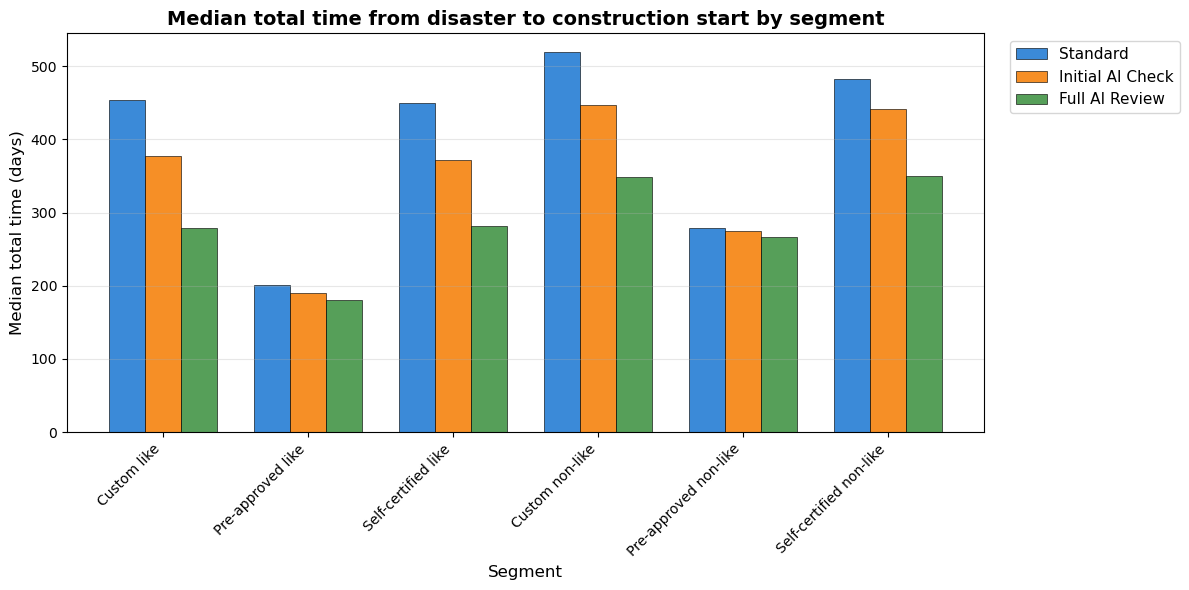

In [5]:
# Compare median total time (disaster to construction) by segment
# Within-run medians across Monte Carlo runs (see runs_by_process from prior cell)
fig, ax = plot_median_total_time_by_process(runs_by_process)
if fig is not None:
    plt.show()

In [6]:
# Diagnostic: non-like-for-like step-level timeline comparison by AI policy
import pandas as pd
from permit_simulation import Segment

NON_LIKE_SEGMENTS = {
    Segment.PRE_APPROVED_NON_LIKE,
    Segment.CUSTOM_NON_LIKE,
    Segment.SELF_CERT_NON_LIKE,
}


def _non_like_step_summary(permits: list) -> dict:
    non_like = [p for p in permits if p.segment in NON_LIKE_SEGMENTS and p.ready_for_construction is not None]
    if not non_like:
        return {"n": 0}

    def _mean(values):
        vals = [v for v in values if v is not None]
        return float(np.mean(vals)) if vals else np.nan

    return {
        "n": len(non_like),
        "total_time": _mean([p.ready_for_construction - p.created_at for p in non_like]),
        "planning_wait": _mean([p.planning_total_waiting for p in non_like]),
        "planning_service": _mean([p.planning_initial_service + p.planning_recheck_service for p in non_like]),
        "public_works_wait": _mean([p.public_works_total_waiting for p in non_like]),
        "public_works_service": _mean([p.public_works_initial_service + p.public_works_recheck_service for p in non_like]),
        "fire_wait": _mean([p.fire_review_total_waiting for p in non_like]),
        "fire_service": _mean([p.fire_initial_service + p.fire_recheck_service for p in non_like]),
        "agency_referral_total": _mean([
            (p.agency_referral_end - p.agency_referral_request)
            if p.agency_referral_request is not None and p.agency_referral_end is not None
            else 0.0
            for p in non_like
        ]),
        "special_zoning_service": _mean([
            (p.zoning_end - p.zoning_start)
            if p.zoning_start is not None and p.zoning_end is not None
            else 0.0
            for p in non_like
        ]),
        "applicant_revisions": _mean([p.applicant_revisions_total_time for p in non_like]),
    }


scenario_non_like = {
    "Standard": _non_like_step_summary(all_standard_permits),
    "Initial AI Check": _non_like_step_summary(all_initial_permits),
    "Full AI Review": _non_like_step_summary(all_full_permits),
}

comparison_df = pd.DataFrame(scenario_non_like).T
comparison_df = comparison_df[[
    "n",
    "total_time",
    "planning_wait",
    "planning_service",
    "public_works_wait",
    "public_works_service",
    "fire_wait",
    "fire_service",
    "agency_referral_total",
    "special_zoning_service",
    "applicant_revisions",
]].round(2)

print("Non-like-for-like diagnostics (mean days):")
display(comparison_df)

if "Standard" in comparison_df.index:
    delta_vs_standard = (comparison_df - comparison_df.loc["Standard"]).round(2)
    print("\nDelta vs Standard (mean days):")
    display(delta_vs_standard)


Non-like-for-like diagnostics (mean days):


,n,total_time,planning_wait,planning_service,public_works_wait,public_works_service,fire_wait,fire_service,agency_referral_total,special_zoning_service,applicant_revisions
Standard,2409.0,520.35,138.13,9.97,0.45,8.36,0.01,3.54,37.96,56.34,93.91
Initial AI Check,2409.0,447.92,68.95,7.27,0.23,6.23,0.01,2.76,38.51,57.66,93.82
Full AI Review,2409.0,369.48,0.00,1.00,0.00,0.83,0.00,0.37,38.64,57.53,94.87



Delta vs Standard (mean days):


,n,total_time,planning_wait,planning_service,public_works_wait,public_works_service,fire_wait,fire_service,agency_referral_total,special_zoning_service,applicant_revisions
Standard,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Initial AI Check,0.0,-72.43,-69.18,-2.70,-0.22,-2.13,0.00,-0.78,0.55,1.32,-0.09
Full AI Review,0.0,-150.87,-138.13,-8.97,-0.45,-7.53,-0.01,-3.17,0.68,1.19,0.96


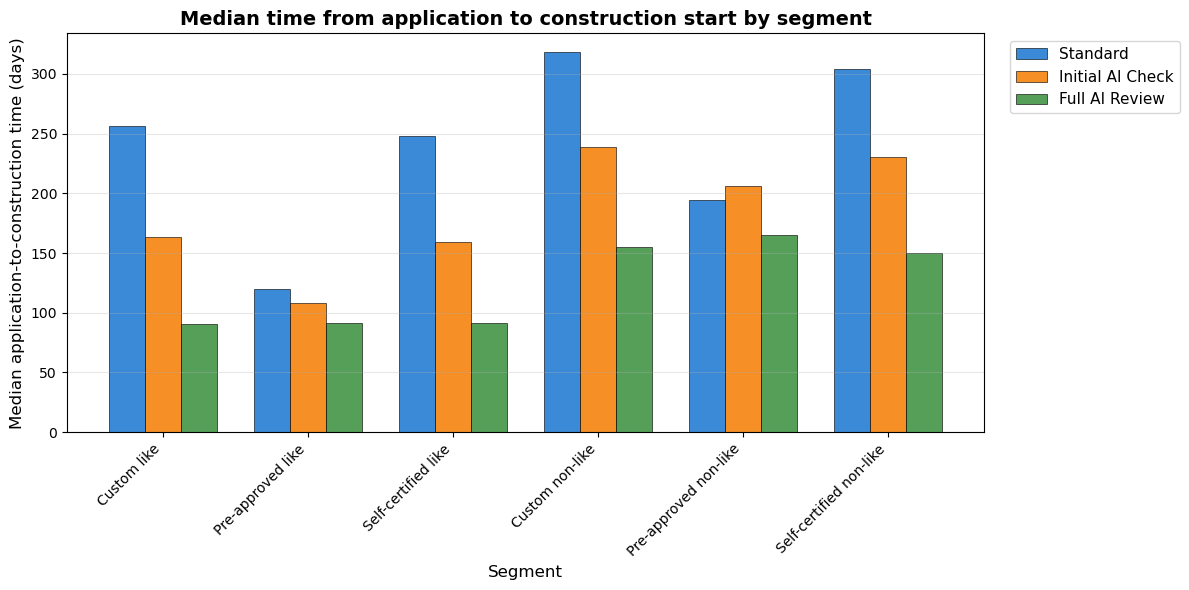

In [7]:
# Compare within-run median application-to-construction time by segment (boxplot across runs)
fig, ax = plot_median_total_time_by_process(
    runs_by_process,
    application_to_ready=True,
    title="Time from application to construction start by segment",
)
if fig is not None:
    plt.show()


In [8]:
# Simulation setup + run for segment-median AI comparisons
from permit_simulation import Segment
from simulation_plot_helpers import permits_by_scenario_partitioned_by_run

N_RUNS_PANEL = 30
BASE_SEED_PANEL = 42
PRE_APP_DIST = "lognormal_180"
PERMIT_COUNTS = [2000, 6500]
STAFFING_ORDER = ["low", "medium", "high"]
AI_SCENARIOS = [
    ("Standard", "none"),
    ("Initial AI Check", "initial_check"),
    ("Full AI Review", "full_review"),
]

STAFFING_SCENARIOS = {
    "low": {"planning_staff_count": 2, "public_works_staff_count": 3, "fire_staff_count": 1},
    "medium": {"planning_staff_count": 8, "public_works_staff_count": 12, "fire_staff_count": 4},
    "high": {"planning_staff_count": 20, "public_works_staff_count": 30, "fire_staff_count": 10},
}

segment_order = [
    Segment.CUSTOM_LIKE,
    Segment.PRE_APPROVED_LIKE,
    Segment.SELF_CERT_LIKE,
    Segment.CUSTOM_NON_LIKE,
    Segment.PRE_APPROVED_NON_LIKE,
    Segment.SELF_CERT_NON_LIKE,
]
segment_labels = [
    "Custom like",
    "Pre-approved like",
    "Self-certified like",
    "Custom non-like",
    "Pre-approved non-like",
    "Self-certified non-like",
]

colors = {
    "Standard": "#1976D2",
    "Initial AI Check": "#F57C00",
    "Full AI Review": "#388E3C",
}

scenario_params_list = []
for n in PERMIT_COUNTS:
    for staffing_name in STAFFING_ORDER:
        for ai_label, ai_mode in AI_SCENARIOS:
            scenario_params_list.append(
                {
                    "name": f"permits={n}|staffing={staffing_name}|ai={ai_label}",
                    "num_permits": n,
                    "pre_application_distribution": PRE_APP_DIST,
                    "sequential": "standard",
                    "ai_review": ai_mode,
                    "permit_mix": "balanced",
                    "review_duration_families": None,
                    "review_duration_multipliers": None,
                    "planning_caseload_per_staff": 7,
                    "public_works_caseload_per_staff": 7,
                    "fire_caseload_per_staff": 7,
                    **STAFFING_SCENARIOS[staffing_name],
                }
            )

results_panel = run_multiple_simulations(
    n_runs=N_RUNS_PANEL,
    base_seed=BASE_SEED_PANEL,
    scenario_params_list=scenario_params_list,
    collect_permits=True,
)

runs_by_scenario = permits_by_scenario_partitioned_by_run(results_panel)

print(f"Completed {len(scenario_params_list)} scenarios × {N_RUNS_PANEL} runs each.")


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x108d4d7f0>>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


Completed 18 scenarios × 30 runs each.


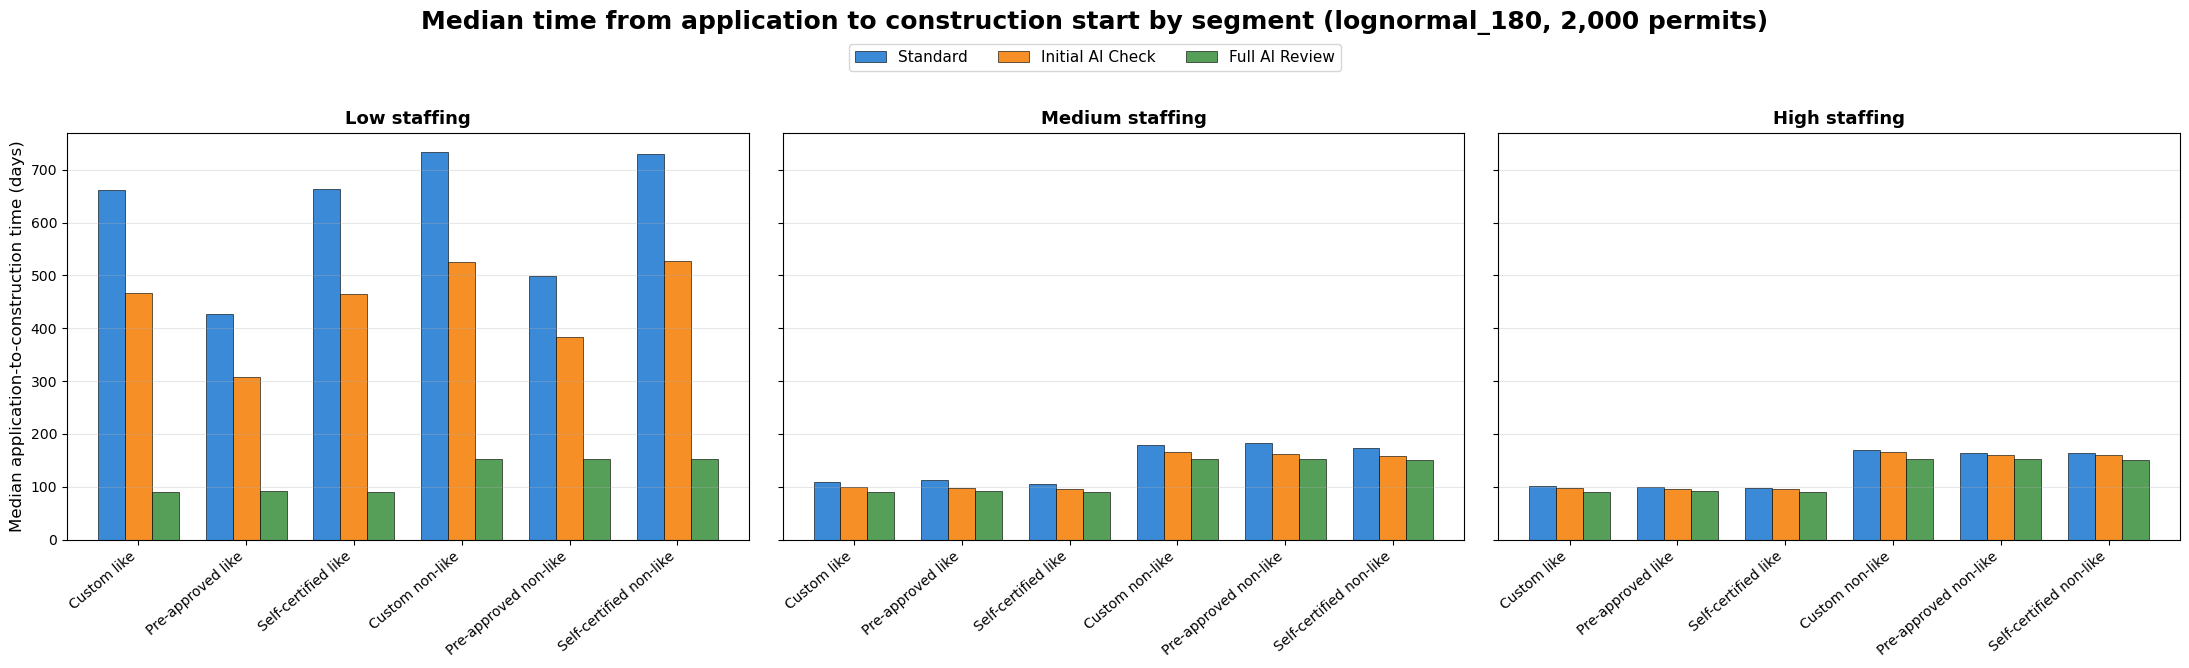

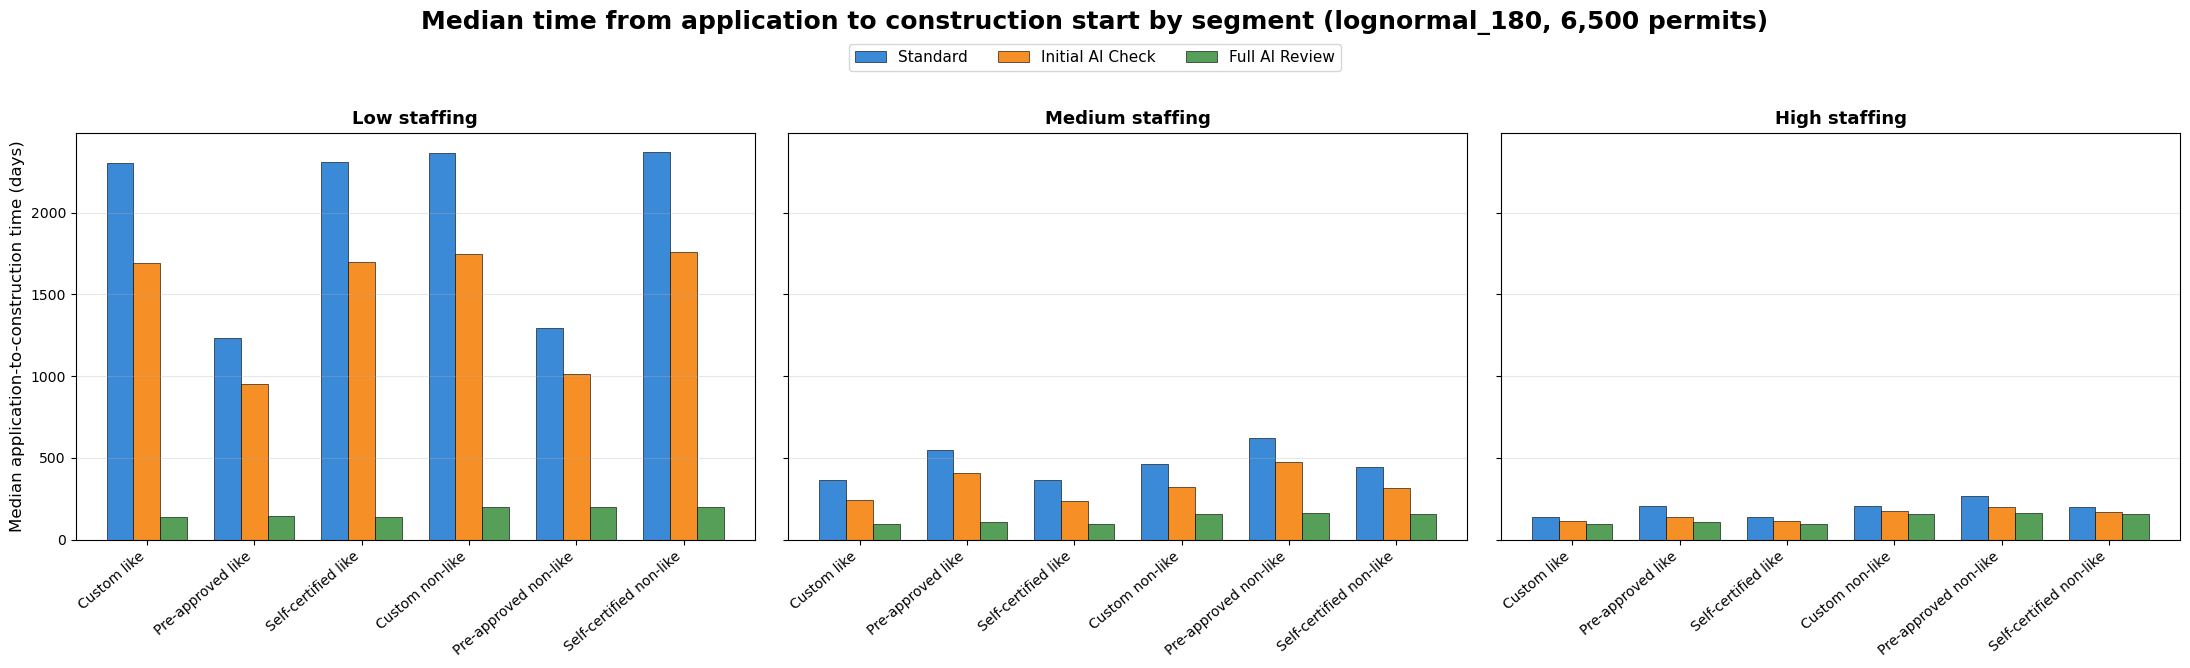

In [10]:
# Plotting: within-run median application→ready by segment; box = spread across runs
import matplotlib.patches as mpatches

for n in PERMIT_COUNTS:
    fig, axes = plt.subplots(1, 3, figsize=(22, 6.5), sharey=True)
    fig.suptitle(
        f"Application to construction by segment — within-run medians across runs (lognormal_180, {n:,} permits)",
        fontsize=18,
        fontweight="bold",
        y=1.02,
    )

    for col, staffing_name in enumerate(STAFFING_ORDER):
        ax = axes[col]
        runs_by_process = {
            ai_label: runs_by_scenario.get(
                f"permits={n}|staffing={staffing_name}|ai={ai_label}", []
            )
            for ai_label, _ in AI_SCENARIOS
        }
        plot_median_total_time_by_process(
            runs_by_process,
            application_to_ready=True,
            ax=ax,
            title=f"{staffing_name.capitalize()} staffing",
            legend=False,
            show_stats_table=True,
        )
        if col > 0:
            ax.set_ylabel("")

    process_names = [a[0] for a in AI_SCENARIOS]
    handles = [
        mpatches.Patch(facecolor=colors[name], alpha=0.85, edgecolor="black", label=name)
        for name in process_names
    ]
    fig.legend(
        handles,
        process_names,
        loc="upper center",
        ncol=3,
        bbox_to_anchor=(0.5, 0.98),
        fontsize=11,
    )

    plt.tight_layout(rect=(0, 0, 1, 0.92))
    plt.show()


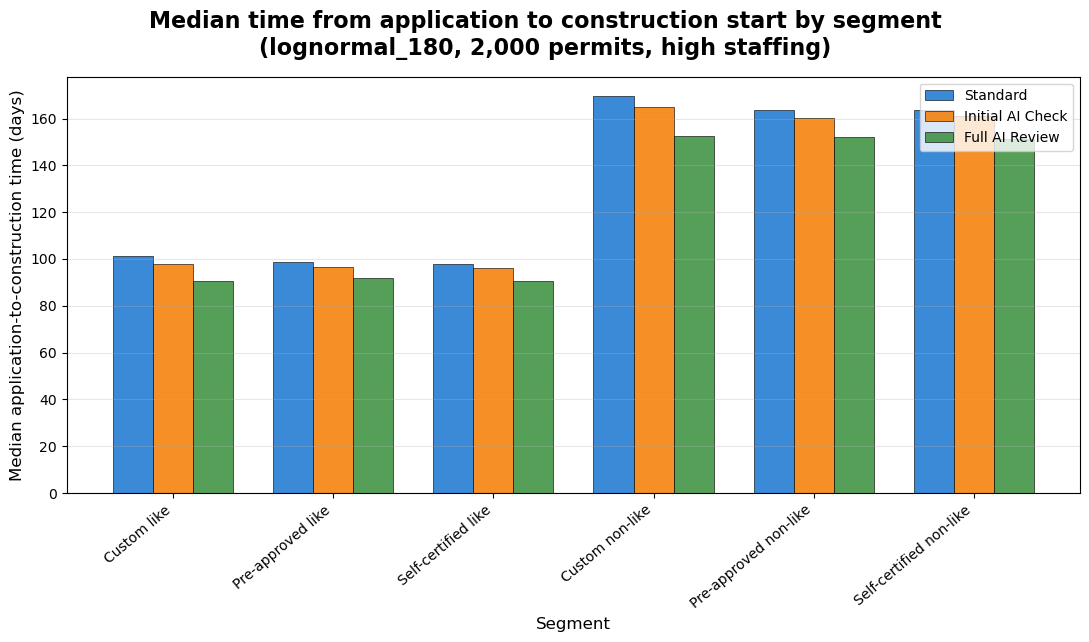

In [11]:
# Plot one selected panel at a time
SELECTED_PERMITS = 2000           # choose: 2000 or 6500
SELECTED_STAFFING = "high"         # choose: "low", "medium", "high"

if SELECTED_PERMITS not in PERMIT_COUNTS:
    raise ValueError(f"SELECTED_PERMITS must be one of {PERMIT_COUNTS}")
if SELECTED_STAFFING not in STAFFING_ORDER:
    raise ValueError(f"SELECTED_STAFFING must be one of {STAFFING_ORDER}")

runs_by_process = {
    ai_label: runs_by_scenario.get(
        f"permits={SELECTED_PERMITS}|staffing={SELECTED_STAFFING}|ai={ai_label}", []
    )
    for ai_label, _ in AI_SCENARIOS
}

fig, ax = plot_median_total_time_by_process(
    runs_by_process,
    application_to_ready=True,
    figsize=(12, 7),
    title=(
        f"Application to construction by segment (lognormal_180, {SELECTED_PERMITS:,} permits, "
        f"{SELECTED_STAFFING} staffing)"
    ),
)
if fig is not None:
    plt.tight_layout()
    plt.show()


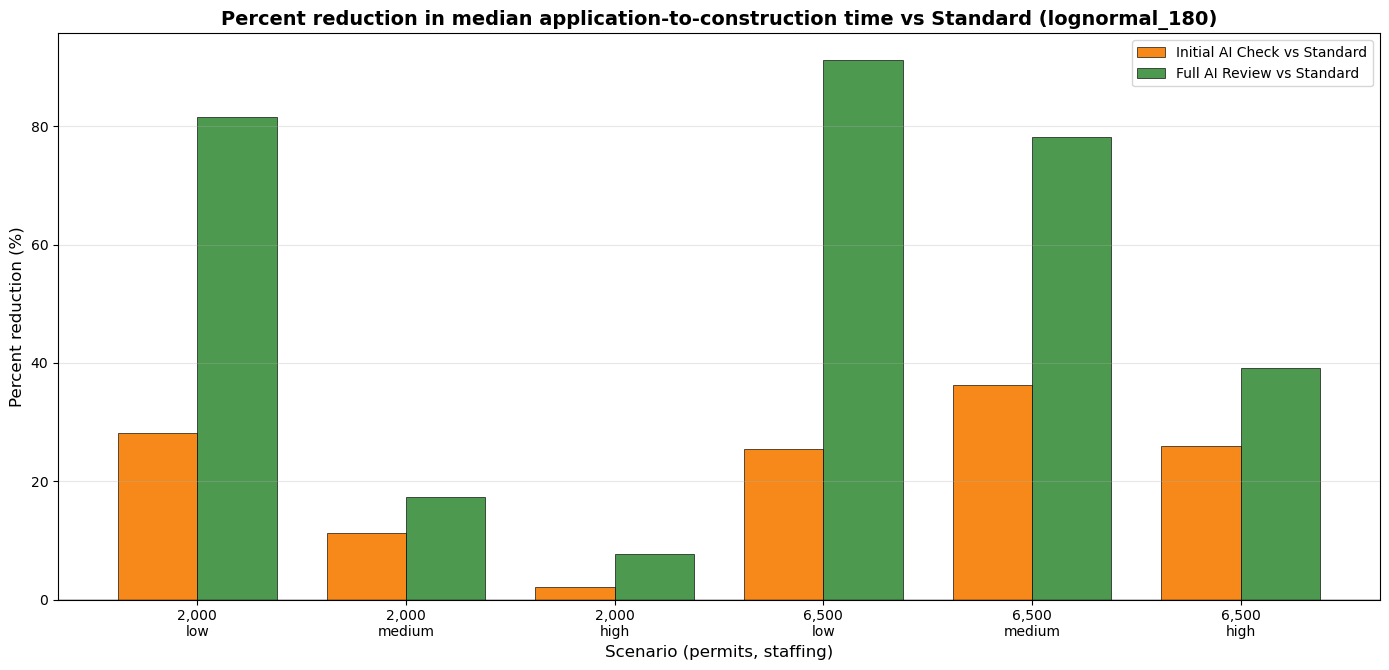

In [13]:
# Percent reduction vs Standard: paired by run_index using within-run median overall app→ready
import matplotlib.patches as mpatches
from simulation_plot_helpers import show_boxplot_stats_table


def _median_app_ready_for_run(run_ps):
    times = [
        float(p.ready_for_construction - p.planning_request)
        for p in run_ps
        if p.ready_for_construction is not None and p.planning_request is not None
    ]
    return float(np.median(times)) if times else float("nan")


scenario_keys = []
scenario_labels = []
for n in PERMIT_COUNTS:
    for staffing in STAFFING_ORDER:
        scenario_keys.append((n, staffing))
        scenario_labels.append(f"{n:,}" + "\n" + staffing)

init_positions, init_data, init_labels = [], [], []
full_positions, full_data, full_labels = [], [], []
group_centers = []
gap = 2.6
pad = 0.34

for gi, (n, staffing) in enumerate(scenario_keys):
    center = gi * gap
    group_centers.append(center)
    runs_s = runs_by_scenario.get(f"permits={n}|staffing={staffing}|ai=Standard", [])
    runs_i = runs_by_scenario.get(f"permits={n}|staffing={staffing}|ai=Initial AI Check", [])
    runs_f = runs_by_scenario.get(f"permits={n}|staffing={staffing}|ai=Full AI Review", [])
    init_reds = []
    full_reds = []
    for rs, ri, rf in zip(runs_s, runs_i, runs_f):
        ms = _median_app_ready_for_run(rs)
        mi = _median_app_ready_for_run(ri)
        mf = _median_app_ready_for_run(rf)
        if not np.isfinite(ms) or ms == 0:
            continue
        if np.isfinite(mi):
            init_reds.append((ms - mi) / ms * 100.0)
        if np.isfinite(mf):
            full_reds.append((ms - mf) / ms * 100.0)
    if init_reds:
        init_positions.append(center - pad)
        init_data.append(init_reds)
        init_labels.append(f"{n:,} permits, {staffing} · Initial vs Standard (%)")
    if full_reds:
        full_positions.append(center + pad)
        full_data.append(full_reds)
        full_labels.append(f"{n:,} permits, {staffing} · Full vs Standard (%)")

fig, ax = plt.subplots(figsize=(14, 6.8))

if init_data:
    bp_i = ax.boxplot(
        init_data,
        positions=init_positions,
        widths=0.52,
        patch_artist=True,
        showfliers=True,
    )
    for patch in bp_i["boxes"]:
        patch.set_facecolor("#F57C00")
        patch.set_alpha(0.9)
        patch.set_edgecolor("black")
if full_data:
    bp_f = ax.boxplot(
        full_data,
        positions=full_positions,
        widths=0.52,
        patch_artist=True,
        showfliers=True,
    )
    for patch in bp_f["boxes"]:
        patch.set_facecolor("#388E3C")
        patch.set_alpha(0.9)
        patch.set_edgecolor("black")

ax.set_title(
    "Percent reduction vs Standard (paired runs; within-run median app→ready, lognormal_180)",
    fontsize=14,
    fontweight="bold",
)
ax.set_ylabel("Percent reduction (%)", fontsize=12)
ax.set_xlabel("Scenario (permits, staffing)", fontsize=12)
ax.set_xticks(group_centers)
ax.set_xticklabels(scenario_labels, fontsize=10)
ax.axhline(0, color="black", linewidth=1.0)
ax.grid(axis="y", alpha=0.3)

handles = [
    mpatches.Patch(facecolor="#F57C00", alpha=0.9, edgecolor="black", label="Initial AI Check vs Standard"),
    mpatches.Patch(facecolor="#388E3C", alpha=0.9, edgecolor="black", label="Full AI Review vs Standard"),
]
ax.legend(handles=handles, fontsize=10)

plt.tight_layout()
plt.show()

show_boxplot_stats_table(
    list(zip(init_labels, init_data)) + list(zip(full_labels, full_data)),
    heading="Percent reduction vs Standard (paired runs; one value per run)",
)
